In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1) generate reproducible toy NHWC image tensor

$N=10, H=W=500, C=3$ `(uint8 RGB)`

In [ ]:
rng = np.random.default_rng(42)
nhwc = rng.integers(
    0, 256, size=(10, 500, 500, 3), dtype=np.uint8
)  # shape (10, 500, 500, 3)
nhwc.shape

(10, 500, 500, 3)

Frames looks like this:

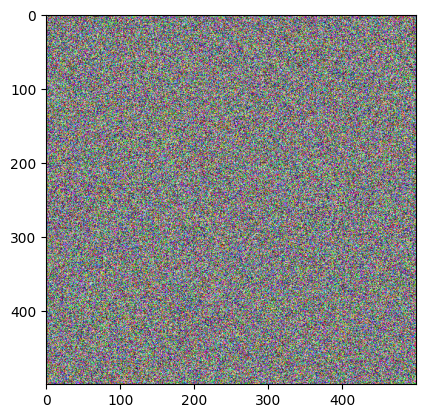

In [14]:
plt.imshow(nhwc[0])

# 2) basic indexing / visualization


In [ ]:
frame0 = nhwc[0]  # shape (500, 500, 3)  — single frame (NHWC -> HWC by indexing)
frame0_batch = nhwc[0:1]  # shape (1, 500, 500, 3) — keeps the batch axis

# squeeze removes length-1 axes
frame0_squeezed = np.squeeze(
    frame0_batch, axis=0
)  # shape (500, 500, 3), same as frame0
print(
    f"Single frame no batch axis: {frame0.shape}\nSingle frame WITH batch axis:{frame0_batch.shape}\nShape (N,W,H,C) array stripped of batch axis {frame0_squeezed.shape}"
)

Single frame no batch axis: (500, 500, 3)
Single frame WITH batch axis:(1, 500, 500, 3)
Shape (N,W,H,C) array stripped of batch axis (500, 500, 3)


# 3) permute / transpose examples

In [ ]:
nchw = np.transpose(nhwc, (0, 3, 1, 2))  # NHWC -> NCHW, shape (10, 3, 500, 500)
nchw.shape

(10, 3, 500, 500)

In [11]:
# alternative: moveaxis moves a given axis to a new position
nchw_alt = np.moveaxis(nhwc, -1, 1)  # same result as transpose above
nchw_alt.shape

(10, 3, 500, 500)

# 4) stack vs concatenate

Stack **creates** a new axis: stacking two frames -> shape $(2, 500, 500, 3)$


In [ ]:
stack_first_two = np.stack([nhwc[0], nhwc[1]], axis=0)
stack_first_two.shape

(2, 500, 500, 3)

Concatenate uses **existing axes**: concatenating two 1-frame batches along axis 0

In [ ]:
concat_first_two = np.concatenate(
    [nhwc[0:1], nhwc[1:2]], axis=0
)  # shape (2, 500, 500, 3)
concat_first_two.shape

(2, 500, 500, 3)

# 5) vstack example

Useful for making a tall visualization

Text(0.5, 1.0, 'frame0 (top) / frame1 (bottom)')

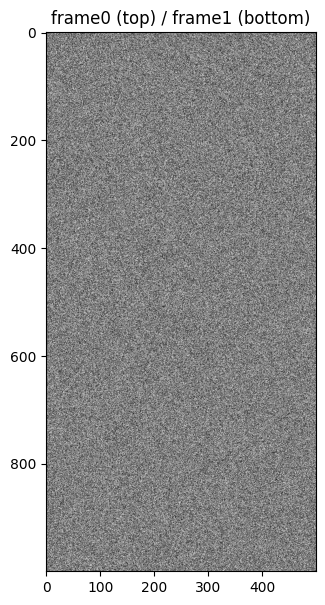

In [ ]:
# convert two frames to grayscale (simple luminance) and vertically stack
def rgb_to_gray_safe(img):
    # img: (H,W,3), dtype uint8 or numeric
    # compute luminance, round and clip to [0,255], return uint8 (H,W)
    lum = 0.2989 * img[..., 0] + 0.5870 * img[..., 1] + 0.1140 * img[..., 2]
    lum = np.rint(lum)  # round rather than truncate
    lum = np.clip(lum, 0, 255)  # ensure valid uint8 range
    return lum.astype(np.uint8)


# assume `nhwc` exists in your session (10,500,500,3)
gray0 = rgb_to_gray_safe(nhwc[0])  # shape (500,500)
gray1 = rgb_to_gray_safe(nhwc[1])  # shape (500,500)

# make the tall visualisation: frame0 on top, frame1 below
vstacked_pair = np.vstack([gray0, gray1])  # shape (1000,500)
# same as: vstacked_pair = np.concatenate([gray0, gray1], axis=0)

# verification booleans (no printing)
top_matches = np.array_equal(vstacked_pair[0 : gray0.shape[0], :], gray0)
bottom_matches = np.array_equal(vstacked_pair[gray0.shape[0] :, :], gray1)

# display the tall image (use cmap='gray' for correct grayscale rendering)
fig, ax = plt.subplots(figsize=(3.5, 7))  # tall aspect for clarity
ax.imshow(vstacked_pair, cmap="gray", vmin=0, vmax=255)
ax.axis("off")
ax.set_title("frame0 (top) / frame1 (bottom)")

# Overlaying segmentation masks

Text(0.5, 1.0, 'RGB frame with green circular mask (alpha=0.45)')

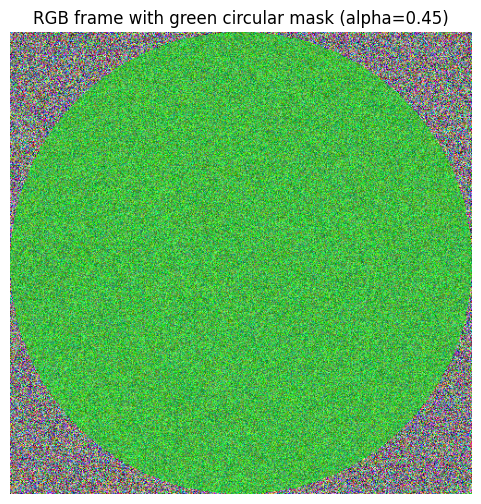

In [ ]:
# --- choose background RGB image (H,W,3 uint8) ---
try:
    bg = frame0  # use existing frame if available in your session
except NameError:
    rng = np.random.default_rng(0)
    bg = rng.integers(0, 256, size=(500, 500, 3), dtype=np.uint8)

H, W = bg.shape[:2]

# --- make a circular boolean mask (diameter = 500 -> radius = 250) ---
cy, cx = (H - 1) / 2.0, (W - 1) / 2.0
r = 250.0
yy, xx = np.ogrid[:H, :W]
mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r**2  # dtype: bool, shape (500,500)

# --- build an RGBA overlay: green where mask is True, else transparent ---
alpha_val = 0.45
alpha_byte = int(round(alpha_val * 255))
overlay = np.zeros((H, W, 4), dtype=np.uint8)
overlay[..., 1] = 255  # green channel (R,G,B,A)
overlay[..., 3] = (mask * alpha_byte).astype(np.uint8)

# --- display: background RGB then RGBA overlay (overlay's alpha channel controls blending) ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(bg)  # HxWx3 uint8 RGB
ax.imshow(overlay, interpolation="nearest")  # RGBA overlay uses overlay[...,3] as alpha
ax.axis("off")
ax.set_title("RGB frame with green circular mask (alpha=0.45)")

## Using natural-language colour selections

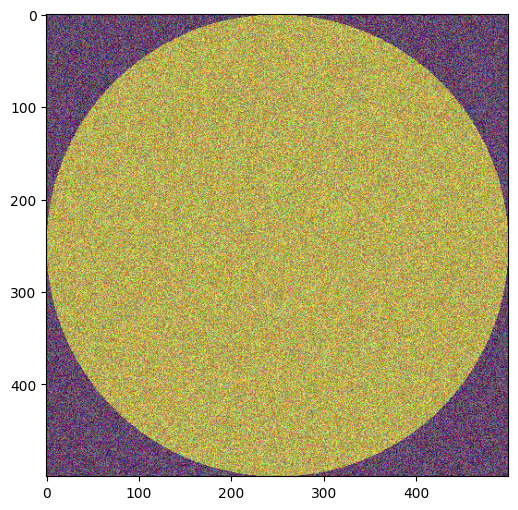

In [ ]:
import numpy as np
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# use existing background and mask if available in the session; otherwise make toy data
try:
    bg = frame0.copy()  # (H, W, 3) uint8
    mask_bool = mask.copy()  # (H, W) bool
except NameError:
    rng = np.random.default_rng(0)
    bg = rng.integers(0, 256, size=(500, 500, 3), dtype=np.uint8)
    H, W = bg.shape[:2]
    yy, xx = np.ogrid[:H, :W]
    mask_bool = (yy - H / 2) ** 2 + (xx - W / 2) ** 2 <= (min(H, W) / 2) ** 2

H, W = bg.shape[:2]
alpha = 0.45  # overlay opacity


# Helper: blend overlay_rgb (H,W,3) floats 0..1 with bg uint8 -> resulting uint8 (H,W,3)
def blend_overlay(bg_uint8, overlay_rgb_float, alpha_float):
    bg_float = bg_uint8.astype(np.float32) / 255.0
    alpha_arr = np.broadcast_to(alpha_float, overlay_rgb_float.shape[:2])[..., None]
    out_float = overlay_rgb_float * alpha_arr + bg_float * (1.0 - alpha_arr)
    out_uint8 = np.clip(np.rint(out_float * 255.0), 0, 255).astype(np.uint8)
    return out_uint8


# A) Single named color from CSS4_COLORS (e.g., "lime" or "crimson")
color_name = "lime"  # pick any CSS4 name from matplotlib.colors.CSS4_COLORS
rgb_float = np.array(mcolors.to_rgb(color_name), dtype=np.float32)  # (3,), 0..1
overlay_rgb_A = np.broadcast_to(
    rgb_float.reshape(1, 1, 3), (H, W, 3)
)  # full-image color
overlay_rgba_A = np.zeros((H, W, 4), dtype=np.uint8)
overlay_rgba_A[..., :3] = (overlay_rgb_A * 255).astype(np.uint8)
overlay_rgba_A[..., 3] = (mask_bool * int(round(alpha * 255))).astype(
    np.uint8
)  # alpha in byte

composited_A = blend_overlay(
    bg, overlay_rgb_A * mask_bool[..., None], alpha
)  # only inside mask

# B) Map mask (or any scalar image) through a matplotlib colormap (e.g., 'viridis')
cmap = matplotlib.colormaps.get_cmap("viridis")  # continuous colormap
# If mask is boolean, convert to floats in [0,1]; if you want edges, use distance or soft values
mask_float = mask_bool.astype(np.float32)  # 0.0 or 1.0
mapped_rgba = cmap(mask_float)  # (H,W,4) floats in 0..1
overlay_rgb_B = mapped_rgba[..., :3].astype(np.float32)  # floats 0..1
overlay_alpha_B = (
    mapped_rgba[..., 3] * alpha
)  # mix cmap alpha (often 1) with requested alpha

# create an actual RGBA uint8 overlay (useful for imshow)
overlay_rgba_B = np.empty((H, W, 4), dtype=np.uint8)
overlay_rgba_B[..., :3] = (overlay_rgb_B * 255.0).astype(np.uint8)
overlay_rgba_B[..., 3] = (np.clip(np.rint(overlay_alpha_B * 255.0), 0, 255)).astype(
    np.uint8
)

composited_B = blend_overlay(
    bg, overlay_rgb_B, overlay_alpha_B
)  # per-pixel alpha blend

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(composited_B)

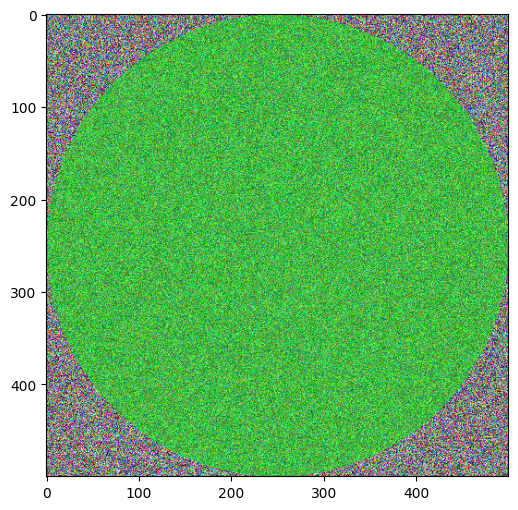

In [25]:
# also demonstrate encoding mask into individual channels (one-hot-ish):
alpha_byte = int(round(alpha * 255))
alpha_chan = (mask_bool * alpha_byte).astype(np.uint8)  # shape (H,W)

encoded = bg.copy()
encoded[..., 0] = np.where(mask_bool, 0, encoded[..., 0])  # zero R inside mask
encoded[..., 1] = np.where(mask_bool, 255, encoded[..., 1])  # set G=255 inside mask
encoded[..., 2] = np.where(mask_bool, 0, encoded[..., 2])  # zero B inside mask
encoded_rgba = np.dstack((encoded, alpha_chan))  # shape (H, W, 4), dtype uint8

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(bg)  # HxWx3 uint8 RGB
ax.imshow(encoded_rgba)  # RGBA overlay uses overlay[...,3]

***

## Using RLE masks (with pycocotools)

In [50]:
import pycocotools.mask as mask_util

In [51]:
# Prepare mask for pycocotools: uint8, Fortran-contiguous
mask_fortran = np.asfortranarray(mask_bool.astype(np.uint8))
mask_fortran

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(500, 500), dtype=uint8)

In [52]:
# 3) Encode to RLE
rle = mask_util.encode(mask_fortran)  # {'size':[H,W], 'counts': b'...'}
# Make JSON-safe representation (COCO: counts stored as ascii)
rle_json_safe = {"size": rle["size"], "counts": rle["counts"].decode("ascii")}
rle_json_safe

{'size': [500, 500],
 'counts': 'j71m>\\1QOb0@>C<E:F:G8H8H8H8I6J6J6J6J6J6K4K6K4L4K6K4L4L4L4K6K4M2M4L4L4L4L4M2M4L4M2M4L4M2M4M2M4M2M4M2N2M4M2M4M2N2N2M4M2N2N2M4M2N2N2N2N2M4M2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2O0O2N2N2N2N2N2O0O2N2N2N2O0O2N2N2N2O0O2N2O0O2N2N2O0O2N2O0O2N2O0O2N2O0O2O0O2N2O0O2O0O2N2O0O2O0O2O0O2O0O2O0O2N2O0O2O000O2O0O2O0O2O0O2O0O2O000O2O0O2O0O2O000O2O0O2O000O2O000O2O000O2O000O2O000O2O000O2O00000O2O00000O2O00000O2O00000O2O0000000O2O0000000O2O000000000O2O00000000000O2O000000000000000O2O0000000000000000000000000000000000000000d?0\\@0000000000000000000000000000000000000000001N10000000000000001N1000000000001N10000000001N100000001N100000001N1000001N1000001N1000001N1000001N10001N10001N10001N10001N10001N10001N101N10001N101N101N10001N101N101N101N101N10001N101N2N101N101N101N101N101N2N101N101N2N101N101N2N101N2N101N2N101N2N2N101N2N101N2N2N2N101N2N2N2N101N2N2N2N2N2N101N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N3L3N2N2N2N2N3L3N2N2N3L3N2N2N3L3N3L3N2N3L3N3L3N3L3N3L4L3N3L4L3N3L4L4L4L4L3N3L5J5L4L4L4L

In [53]:
# 4) Reconstruct RLE from JSON-safe and decode
rle_restored = {
    "size": rle_json_safe["size"],
    "counts": rle_json_safe["counts"].encode("ascii"),
}
decoded_u8 = mask_util.decode(rle_restored)  # uint8 array shape (H,W)
decoded_bool = decoded_u8.astype(bool)
decoded_bool

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(500, 500))

In [54]:
# sanity: decoded_bool should equal mask_bool
equal_mask = np.array_equal(decoded_bool, mask_bool)
equal_mask

True

In [55]:
def single_mask_to_rle(mask: np.ndarray) -> dict:
    """
    Convert a single binary mask to COCO RLE format.

    Args:
        mask: HxW binary mask (uint8 or bool)

    Returns:
        dict with 'counts' (str) and 'size' ([H, W])
    """
    rle = mask_util.encode(np.array(mask[:, :, None], order="F", dtype="uint8"))[0]
    rle["counts"] = rle["counts"].decode("utf-8")
    if "size" in rle and isinstance(rle["size"], (list, tuple)):
        rle["size"] = [int(rle["size"][0]), int(rle["size"][1])]
    return rle

In [56]:
single_mask_to_rle(mask_bool)

{'size': [500, 500],
 'counts': 'j71m>\\1QOb0@>C<E:F:G8H8H8H8I6J6J6J6J6J6K4K6K4L4K6K4L4L4L4K6K4M2M4L4L4L4L4M2M4L4M2M4L4M2M4M2M4M2M4M2N2M4M2M4M2N2N2M4M2N2N2M4M2N2N2N2N2M4M2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2O0O2N2N2N2N2N2O0O2N2N2N2O0O2N2N2N2O0O2N2O0O2N2N2O0O2N2O0O2N2O0O2N2O0O2O0O2N2O0O2O0O2N2O0O2O0O2O0O2O0O2O0O2N2O0O2O000O2O0O2O0O2O0O2O0O2O000O2O0O2O0O2O000O2O0O2O000O2O000O2O000O2O000O2O000O2O000O2O00000O2O00000O2O00000O2O00000O2O0000000O2O0000000O2O000000000O2O00000000000O2O000000000000000O2O0000000000000000000000000000000000000000d?0\\@0000000000000000000000000000000000000000001N10000000000000001N1000000000001N10000000001N100000001N100000001N1000001N1000001N1000001N1000001N10001N10001N10001N10001N10001N10001N101N10001N101N101N10001N101N101N101N101N10001N101N2N101N101N101N101N101N2N101N101N2N101N101N2N101N2N101N2N101N2N2N101N2N101N2N2N2N101N2N2N2N101N2N2N2N2N2N101N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N2N3L3N2N2N2N2N3L3N2N2N3L3N2N2N3L3N3L3N2N3L3N3L3N3L3N3L4L3N3L4L3N3L4L4L4L4L3N3L5J5L4L4L4L

Text(0.5, 1.0, 'Background with decoded circular mask overlay')

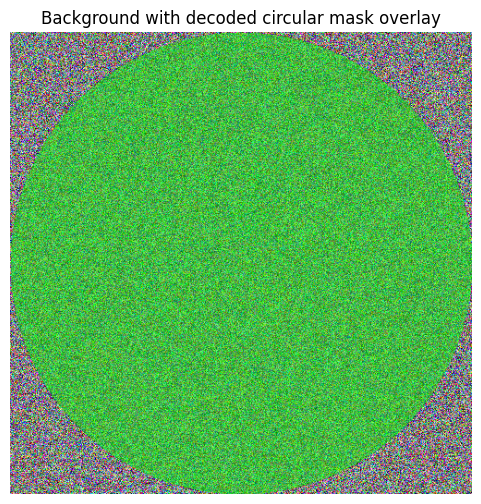

In [ ]:
# 5) Build RGBA overlay (green) and composite onto a background RGB image
# background: use existing `bg` if available, else create a toy background
try:
    bg_rgb = bg.copy()  # use background from your session if present
except NameError:
    rng = np.random.default_rng(0)
    bg_rgb = rng.integers(0, 256, size=(H, W, 3), dtype=np.uint8)

alpha = 0.45
alpha_byte = int(round(alpha * 255))

# RGBA overlay: set green channel to 255 inside mask, alpha to alpha_byte inside mask
overlay_rgba = np.zeros((H, W, 4), dtype=np.uint8)
overlay_rgba[..., 1] = np.where(decoded_bool, 255, 0)  # G channel
overlay_rgba[..., 3] = np.where(decoded_bool, alpha_byte, 0).astype(np.uint8)

# 6) Manual compositing to produce final RGB image (useful if you need the pixels)
overlay_rgb_float = overlay_rgba[..., :3].astype(np.float32) / 255.0
alpha_float = overlay_rgba[..., 3].astype(np.float32) / 255.0
bg_float = bg_rgb.astype(np.float32) / 255.0
out_float = overlay_rgb_float * alpha_float[..., None] + bg_float * (
    1.0 - alpha_float[..., None]
)
composited_rgb = (np.clip(np.rint(out_float * 255.0), 0, 255)).astype(np.uint8)

# 7) (Optional) display using matplotlib (imshow accepts uint8 RGBA and will blend automatically)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(bg_rgb)
ax.imshow(overlay_rgba)
ax.axis("off")
ax.set_title("Background with decoded circular mask overlay")